# Actividad 5.1 (ANOVA)

In [113]:
#Cargamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
df=pd.read_csv("DataAnalytics.csv")




df["botón correcto"]=df["botón correcto"].fillna(method="ffill") ###
df["tiempo de interacción"]=df["tiempo de interacción"].fillna(method="ffill")
df["mini juego"]=df["mini juego"].fillna(method="ffill")
df["número de interacción"]=df["número de interacción"].fillna(method="ffill")
df["color presionado"]=df["color presionado"].fillna(method="ffill")



df["auto push"]=df["auto push"].fillna(method="ffill")
df["tiempo de lección"]=df["tiempo de lección"].fillna(0)
df["tiempo de sesión"]=df["tiempo de sesión"].fillna(0)
df.head()

/var/folders/g2/ww78rm_s75z1d2tynldmz1_m0000gn/T/ipykernel_5698/3147511675.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["botón correcto"]=df["botón correcto"].fillna(method="ffill") ###
/var/folders/g2/ww78rm_s75z1d2tynldmz1_m0000gn/T/ipykernel_5698/3147511675.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["tiempo de interacción"]=df["tiempo de interacción"].fillna(method="ffill")
/var/folders/g2/ww78rm_s75z1d2tynldmz1_m0000gn/T/ipykernel_5698/3147511675.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["mini juego"]=df["mini juego"].fillna(method="ffill")
/var/folders/g2/ww78rm_s75z1d2tynldmz1_m0000gn/T/ipykernel_5698/3147511675.py:17: FutureWarning: Series.fillna with 'method' is deprecated and w

,Administrador,Usuario,botón correcto,tiempo de interacción,mini juego,número de interacción,color presionado,dificultad,fecha,Juego,auto push,tiempo de lección,tiempo de sesión
0,nicolas,nicolas,1.0,5.399169,Despegue,1.0,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,0.0,0.0,0.0
1,nicolas,nicolas,0.0,1.283400,Despegue,2.0,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,0.0,0.0
2,nicolas,nicolas,1.0,2.700226,Despegue,3.0,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,0.0,0.0,0.0
3,nicolas,nicolas,0.0,3.050262,Despegue,4.0,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,0.0,0.0
4,nicolas,nicolas,0.0,4.750256,Despegue,5.0,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,0.0,0.0


## Tiempo de interacción

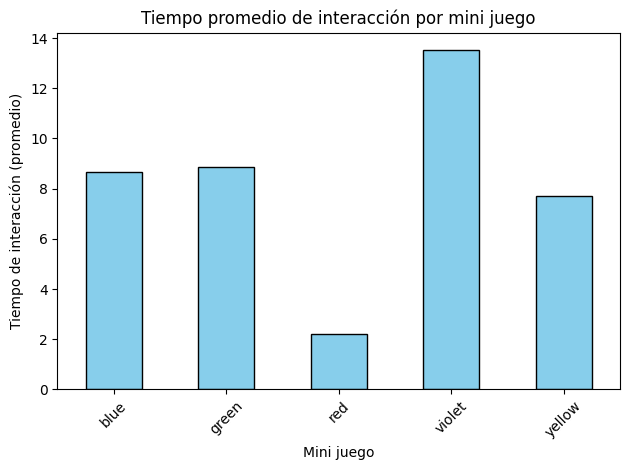

In [115]:
df = df[df['color presionado'] != 100]

tabla1=df.groupby(['color presionado'])['tiempo de interacción'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tiempo promedio de interacción por mini juego')
plt.xlabel('Mini juego')
plt.ylabel('Tiempo de interacción (promedio)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [116]:
#Obtengo las categorías de la variable (sex)
grupos=pd.unique(df['color presionado'].values)
grupos

array(['blue', 'violet', 'green', 'yellow', 'red'], dtype=object)

In [117]:
Fare_1 = df['tiempo de interacción'][df['color presionado'] == 'red']
Fare_2 = df['tiempo de interacción'][df['color presionado'] == 'blue']
Fare_3 = df['tiempo de interacción'][df['color presionado'] == 'green']
Fare_4 = df['tiempo de interacción'][df['color presionado'] == 'violet']
Fare_5 = df['tiempo de interacción'][df['color presionado'] == 'yellow']


In [118]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(39.78051167334246), pvalue=np.float64(6.346335665973705e-33))

In [119]:
# Renombrar las columnas para eliminar los espacios
df.columns = df.columns.str.replace(' ', '_')

# Realiza el análisis con los nuevos nombres
mod = ols('tiempo_de_interacción ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)



                      df        sum_sq       mean_sq          F         PR(>F)
mini_juego          12.0  1.472406e+05  12270.046288  66.690476  6.201574e-153
dificultad           3.0  2.862048e+04   9540.161225  51.852933   4.544849e-33
color_presionado     4.0  2.094869e+04   5237.172067  28.465214   1.852842e-23
Residual          5845.0  1.075392e+06    183.984986        NaN            NaN


## botón correcto

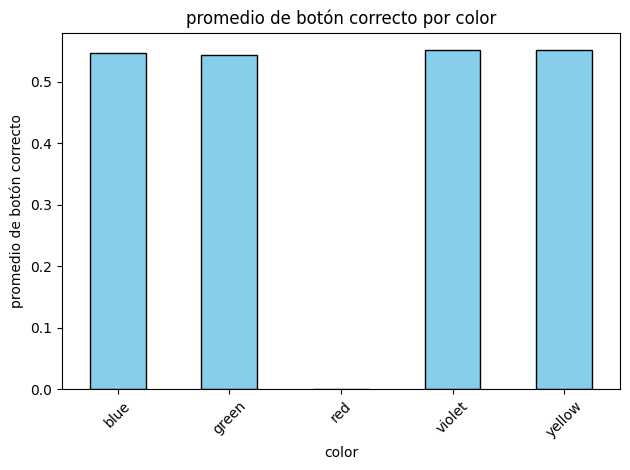

In [120]:
tabla1=df.groupby(['color_presionado'])['botón_correcto'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('promedio de botón correcto por color')
plt.xlabel('color')
plt.ylabel('promedio de botón correcto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [121]:
Fare_1 = df['botón_correcto'][df['color_presionado'] == 'red']
Fare_2 = df['botón_correcto'][df['color_presionado'] == 'blue']
Fare_3 = df['botón_correcto'][df['color_presionado'] == 'green']
Fare_4 = df['botón_correcto'][df['color_presionado'] == 'violet']
Fare_5 = df['botón_correcto'][df['color_presionado'] == 'yellow']

In [122]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(10.367530108037341), pvalue=np.float64(2.29525870097196e-08))

In [123]:

# Realiza el análisis con los nuevos nombres
mod = ols('botón_correcto ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)


                      df       sum_sq   mean_sq          F        PR(>F)
mini_juego          12.0    36.318521  3.026543  12.591310  7.851070e-26
dificultad           3.0     2.682803  0.894268   3.720416  1.093395e-02
color_presionado     4.0    10.371418  2.592854  10.787036  1.036265e-08
Residual          5845.0  1404.948827  0.240368        NaN           NaN


## número de interacción

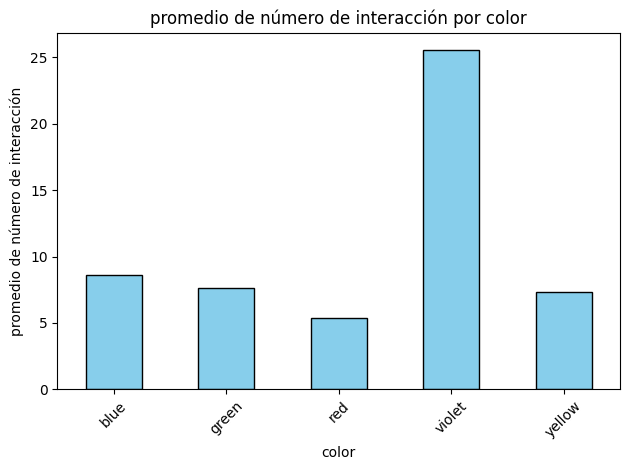

In [124]:
tabla1=df.groupby(['color_presionado'])['número_de_interacción'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('promedio de número de interacción por color')
plt.xlabel('color')
plt.ylabel('promedio de número de interacción')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [125]:
Fare_1 = df['número_de_interacción'][df['color_presionado'] == 'red']
Fare_2 = df['número_de_interacción'][df['color_presionado'] == 'blue']
Fare_3 = df['número_de_interacción'][df['color_presionado'] == 'green']
Fare_4 = df['número_de_interacción'][df['color_presionado'] == 'violet']
Fare_5 = df['número_de_interacción'][df['color_presionado'] == 'yellow']

In [126]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(108.22863977000335), pvalue=np.float64(4.0804207867558766e-89))

In [127]:

# Realiza el análisis con los nuevos nombres
mod = ols('número_de_interacción ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                      df        sum_sq       mean_sq           F  \
mini_juego          12.0  9.098410e+05  75820.079418  108.309089   
dificultad           3.0  1.084491e+05  36149.703330   51.639901   
color_presionado     4.0  2.343572e+05  58589.289483   83.694881   
Residual          5845.0  4.091701e+06    700.034322         NaN   

                         PR(>F)  
mini_juego        5.156769e-244  
dificultad         6.192235e-33  
color_presionado   3.247013e-69  
Residual                    NaN  


## auto push

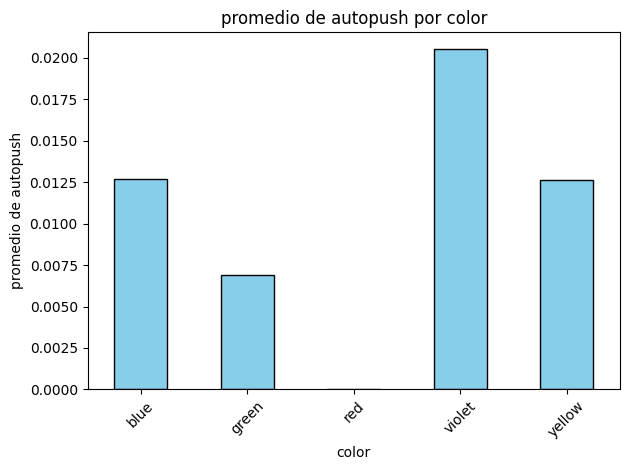

In [128]:
tabla1=df.groupby(['color_presionado'])['auto_push'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('promedio de autopush por color')
plt.xlabel('color')
plt.ylabel('promedio de autopush')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [129]:
Fare_1 = df['auto_push'][df['color_presionado'] == 'red']
Fare_2 = df['auto_push'][df['color_presionado'] == 'blue']
Fare_3 = df['auto_push'][df['color_presionado'] == 'green']
Fare_4 = df['auto_push'][df['color_presionado'] == 'violet']
Fare_5 = df['auto_push'][df['color_presionado'] == 'yellow']

In [130]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(2.878531482757416), pvalue=np.float64(0.021439970874512812))

In [131]:

# Realiza el análisis con los nuevos nombres
mod = ols('auto_push ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                      df     sum_sq   mean_sq          F        PR(>F)
mini_juego          12.0   2.076295  0.173025  13.546918  4.192743e-28
dificultad           3.0   0.072721  0.024240   1.897882  1.276307e-01
color_presionado     4.0   0.159870  0.039967   3.129244  1.396125e-02
Residual          5845.0  74.653775  0.012772        NaN           NaN


## tiempo de lección

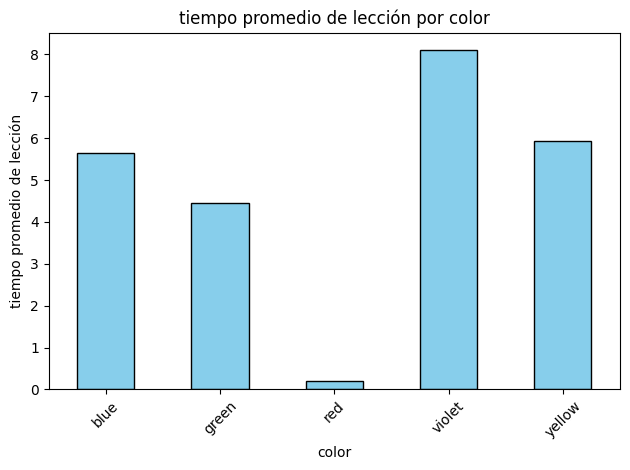

In [134]:
tabla1=df.groupby(['color_presionado'])['tiempo_de_lección'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('tiempo promedio de lección por color')
plt.xlabel('color')
plt.ylabel('tiempo promedio de lección')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [140]:
Fare_1 = df['tiempo_de_lección'][df['color_presionado'] == 'red']
Fare_2 = df['tiempo_de_lección'][df['color_presionado'] == 'blue']
Fare_3 = df['tiempo_de_lección'][df['color_presionado'] == 'green']
Fare_4 = df['tiempo_de_lección'][df['color_presionado'] == 'violet']
Fare_5 = df['tiempo_de_lección'][df['color_presionado'] == 'yellow']

In [141]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(4.558686751742421), pvalue=np.float64(0.001122987490936694))

In [142]:
# Realiza el análisis con los nuevos nombres
mod = ols('tiempo_de_lección ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                      df        sum_sq      mean_sq         F        PR(>F)
mini_juego          12.0  3.572399e+04  2976.999483  4.573501  2.071608e-07
dificultad           3.0  3.621447e+03  1207.148898  1.854517  1.350131e-01
color_presionado     4.0  9.990116e+03  2497.529091  3.836901  4.063314e-03
Residual          5845.0  3.804648e+06   650.923600       NaN           NaN


## tiempo de sesión

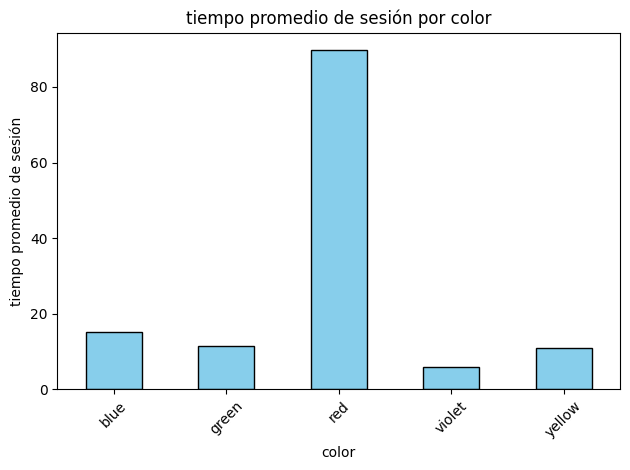

In [138]:
tabla1=df.groupby(['color_presionado'])['tiempo_de_sesión'].mean()
import matplotlib.pyplot as plt

tabla1.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('tiempo promedio de sesión por color')
plt.xlabel('color')
plt.ylabel('tiempo promedio de sesión')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [143]:
Fare_1 = df['tiempo_de_sesión'][df['color_presionado'] == 'red']
Fare_2 = df['tiempo_de_sesión'][df['color_presionado'] == 'blue']
Fare_3 = df['tiempo_de_sesión'][df['color_presionado'] == 'green']
Fare_4 = df['tiempo_de_sesión'][df['color_presionado'] == 'violet']
Fare_5 = df['tiempo_de_sesión'][df['color_presionado'] == 'yellow']

In [144]:
#p-value < 0.05, se rechaza la hipótesis de que todas las medias son iguales
#p-value < 0.05, implica que la variable categórica influye en la variable 
# cuantitativa
anova= stats.f_oneway(Fare_1, Fare_2, Fare_3, Fare_4, Fare_5)
anova

F_onewayResult(statistic=np.float64(6.495065542291799), pvalue=np.float64(3.273143010568765e-05))

In [145]:
# Realiza el análisis con los nuevos nombres
mod = ols('tiempo_de_sesión ~ mini_juego + dificultad + color_presionado', data=df).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                      df        sum_sq        mean_sq          F        PR(>F)
mini_juego          12.0  9.812214e+04    8176.845040   0.772421  6.797443e-01
dificultad           3.0  9.058354e+05  301945.144935  28.523072  2.651951e-18
color_presionado     4.0  2.225910e+05   55647.749837   5.256732  3.177136e-04
Residual          5845.0  6.187515e+07   10585.996807        NaN           NaN
